# Tarea 1: Predicción de resultados del fútbol uruguayo

Este notebook construye modelos para predecir si gana el equipo local (`L`), gana el visitante (`V`) o termina en empate (`E`). El flujo se ejecuta en orden desde la carga del archivo hasta la comparación entre un árbol de decisión y un bosque aleatorio.

---
## **Preprocesamiento**

### 1. Preparación y carga de los datos

Se importan las librerías utilizadas durante el análisis y se define la ubicación del archivo CSV. La celda de instalación es opcional: solo debe ejecutarse si alguna dependencia no está disponible en el entorno local.


In [49]:
# Ejecutar solo si faltan dependencias en el entorno actual
# %pip install pandas numpy matplotlib scikit-learn

In [50]:
from functions import load_csv

dataset = load_csv.load()

Cantidad inicial de instancias: 15207
Cantidad inicial de atributos: 17


### Descripción de los atributos:

| Atributo | Descripción |
| :--- | :--- |
| **`home`** | Nombre del equipo local (no necesariamente único) |
| **`away`** | Nombre del equipo visitante (no necesariamente único) |
| **`date`** | Fecha del partido |
| **`gh`** | Goles del equipo local (incluyendo tiempo extra y penales) |
| **`ga`** | Goles del equipo visitante (incluyendo tiempo extra y penales) |
| **`full_time`** | "F"=el partido terminó en 90', "E"=tiempo extra, "P"=penales |
| **`competition`** | Nombre del país de la liga o nombre de la competición int. |
| **`home_ident`** | Identificador único del equipo local |
| **`away_ident`** | Identificador único del equipo visitante |
| **`home_country`** | País del equipo local |
| **`away_country`** | País del equipo visitante |
| **`home_code`** | Código de país del equipo local |
| **`away_code`** | Código de país del equipo visitante |
| **`home_continent`** | Continente del equipo local |
| **`away_continent`** | Continente del equipo visitante |
| **`continent`** | Continente de la competición |
| **`level`** | "national"= liga local, "international"= copa internacional |

### 2. Eliminación de duplicados

In [51]:
from functions import remove_duplicates

dataset = remove_duplicates.remove(dataset)

Duplicados eliminados: 1
Instancias restantes: 15206


### 3. Definición de la Variable Objetivo (`ganador`)

El objetivo del modelo es predecir el resultado final de un partido de fútbol, clasificándolo en una de tres categorías posibles: victoria local, victoria visitante o empate.

Dado que el dataset original no incluye directamente una columna de resultado, se deduce la variable objetivo **`ganador`** mediante la comparación de los goles anotados por el equipo local (`gh`) y el visitante (`ga`):

* Si $\text{gh} > \text{ga} \implies$ **`L`**
* Si $\text{ga} > \text{gh} \implies$ **`V`**
* Si $\text{gh} == \text{ga} \implies$ **`E`**

In [52]:
from functions import calculate_objective_var

dataset = calculate_objective_var.calculate(dataset)

Una vez creada la variable ganador, los atributos `gh` y `ga` dejan de ser necesarios como entrada directa al modelo, ya que toda la información que contienen quedó capturada en la nueva columna. Sin embargo, estos valores de goles aún serán utilizados en una etapa posterior para construir atributos históricos de cada equipo —como la cantidad de goles anotados y recibidos en sus últimos partidos— por lo que su eliminación del dataset se realizará recién una vez que esos cálculos hayan sido completados.

### 4. Selección de Atributos

En esta etapa del preprocesamiento se realiza una selección de los atributos del dataset con el objetivo de maximizar la capacidad de aprendizaje del modelo. Para ello, se examina cada atributo de forma individual para evaluar si contribuye de manera significativa al entrenamiento o si, dadas sus características, puede ser removido sin perjudicar el desempeño del modelo.

Se evalúan las siguientes condiciones de los atributos:

* **Atributos constantes:** No contribuyen al aprendizaje del modelo debido a que mantienen el mismo valor para todas las instancias del dataset (varianza cero).
* **Atributos redundantes:** Representan valores equivalentes dentro del dataset, por lo que basta con conservar uno de ellos.

Posteriormente, estos atributos se excluyen del dataset para que no formen parte del entrenamiento del modelo.

#### 4.A. Detección de Atributos Constantes

In [53]:
from functions import remove_constant_features

dataset = remove_constant_features.remove(dataset)

Atributos constantes detectados:
competition       1
home_country      1
away_country      1
home_code         1
away_code         1
home_continent    1
away_continent    1
continent         1
level             1
dtype: int64


Los atributos constantes son los siguientes:
* `competition`, `home_country`, `away_country` (Todos refieren a Uruguay).
* `home_code`, `away_code` (Código constante `UY`).
* `home_continent`, `away_continent`, `continent` (Todos refieren a `South America`).
* `level` (Constante con el valor `national`).

#### 4.B. Detección de Atributos Redundantes

In [54]:
from functions import remove_redundant_features

dataset = remove_redundant_features.remove(dataset)

Cada valor de home se corresponde a un solo valor de home_ident, y viceversa:  True
Cada valor de away se corresponde a un solo valor de away_ident, y viceversa:  True


Existe una correspondencia 1:1, mantener ambas variables introduciría información redundante. Elegimos quedarnos con `home` y `away` y se descartan sus identificadores (`home_ident` y `away_ident`).

**Obervación**: La aplicación de este método "a mano" para identificar a los atributos redundantes es más que suficiente para el dataset con el que estamos trabajando, sin embargo, si se tratara de un dataset con una cantidad más grande de atributos entonces sería necesario automatizar de alguna forma la identificación de los atributos redundantes.

### 5. Descomposición del atributo `date`

El atributo `date` se divide en los atributos `day`, `month` y `year` para representar sus componentes por separado. Esta transformación facilita que el modelo identifique patrones relacionados con el momento del año en que se disputó el partido, como diferencias entre meses, temporadas o períodos históricos. Además, evita tratar cada fecha completa como un valor independiente, lo que podría dificultar el aprendizaje. 

Por otro lado, el atributo `year` es necesario para poder dividir el dataset de la forma indicada, más adelante.
El atributo `date` se preserva por el momento porque lo utilizaremos más adelante con el objetivo de ordenar el dataset de forma cronológica para crear atributos históricos.

In [55]:
import pandas as pd

dataset["date"] = pd.to_datetime(dataset["date"])
dataset["day"] = dataset["date"].dt.day
dataset["month"] = dataset["date"].dt.month
dataset["year"] = dataset["date"].dt.year

dataset.head(5)

,home,away,date,gh,ga,full_time,ganador,day,month,year
0,Bella Vista,Defensor Sporting,1932-03-05,1.0,2.0,F,V,5,3,1932
1,CA Penarol,River Plate,1932-03-05,1.0,1.0,F,E,5,3,1932
2,Montevideo Wanderers,Racing Club,1932-03-05,3.0,0.0,F,L,5,3,1932
3,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1.0,0.0,F,L,5,3,1932
4,Nacional,Institucion Atletica Sud America,1932-03-05,2.0,0.0,F,L,5,3,1932


### 6. Creación de atributos históricos

Para cada equipo (local y visitante) se calculan los siguientes atributos históricos:

* Victorias en últimos 5 partidos (de Local o de Visitante)
* Goles anotados en últimos 5 partidos (de Local o de Visitante)
* Goles recibidos en últimos 5 partidos (de Local o de Visitante)
* Días desde el último partido (90 si no hay historial)
* Victorias en últimos 5 partidos como Visitante
* Victorias en últimos 5 partidos como Local

Estas variables se calculan ordenando los partidos por fecha y agrupándolos por temporada (año) y equipo. De esta forma, los atributos se calculan en base a una misma temporada.

**Observación**: En el caso de los días de descanso para un equipo que jugará su primera fecha en el campeonato, se asigna un valor por defecto que representa una cantidad estándar de días de descanso desde el último partido disputado en la temporada anterior.

In [56]:
from functions import historic_features
dataset = historic_features.calculate_historic_features(dataset, window=5)

Posteriormente, se remueven de la entrada de los modelos las columnas que ya cumplieron su función en el preprocesamiento. `gh` y `ga` fueron utilizados para calcular las rachas de goles, por lo que ya no aportan información adicional al modelo. Del atributo `date`, nos quedamos con la desomposicion de `day`, `year` y `month`, que es utilizada para calcular `dias_descanso`, por lo que su presencia es ahora redundante.

In [57]:
dataset = dataset.drop(columns=['gh', 'ga', 'date'])
dataset.head()

,home,away,full_time,ganador,day,month,year,local_wins_last_5,home_wins_last_5,local_goals_scored_last_5,local_goals_conceded_last_5,local_dias_descanso,visita_wins_last_5,away_wins_last_5,visita_goals_scored_last_5,visita_goals_conceded_last_5,visita_dias_descanso
0,Bella Vista,Defensor Sporting,F,V,5,3,1932,0,0,0,0,90,0,0,0,0,90
1,CA Penarol,River Plate,F,E,5,3,1932,0,0,0,0,90,0,0,0,0,90
2,Montevideo Wanderers,Racing Club,F,L,5,3,1932,0,0,0,0,90,0,0,0,0,90
3,Central Espanol,Rampla Juniors Futbol Club,F,L,5,3,1932,0,0,0,0,90,0,0,0,0,90
4,Nacional,Institucion Atletica Sud America,F,L,5,3,1932,0,0,0,0,90,0,0,0,0,90


### 7. Discretizacion de atributos: 
 Se discretizan los valores de los atributos continuos: `local_dias_descanso` y `visita_dias_descanso`, dividiéndolos en tres categorías o rangos: `minimo` (< 7 días), `intermedio` (7 a 15 días) y `alto` (> 15 días). Esta estrategia permite facilitar el manejo de atributos continuos por parte de los modelos, pasando a considerarse como atributos categóricos.

In [58]:
import numpy as np

bins_descanso = [-np.inf, 6, 15, np.inf]
etiquetas_descanso = ['minimo', 'intermedio', 'alto']

for columna in ['local_dias_descanso', 'visita_dias_descanso']:
    dataset[columna] = pd.cut(dataset[columna], bins=bins_descanso, labels=etiquetas_descanso)

categorical_features = [
    'home',
    'away',
    'local_dias_descanso',
    'visita_dias_descanso'
]
numeric_features = [
    'month',
    'local_wins_last_5',
    'visita_wins_last_5',
    'home_wins_last_5',
    'away_wins_last_5',
    'local_goals_scored_last_5',
    'local_goals_conceded_last_5',
    'visita_goals_scored_last_5',
    'visita_goals_conceded_last_5',
]

dataset.head(5)

,home,away,full_time,ganador,day,month,year,local_wins_last_5,home_wins_last_5,local_goals_scored_last_5,local_goals_conceded_last_5,local_dias_descanso,visita_wins_last_5,away_wins_last_5,visita_goals_scored_last_5,visita_goals_conceded_last_5,visita_dias_descanso
0,Bella Vista,Defensor Sporting,F,V,5,3,1932,0,0,0,0,alto,0,0,0,0,alto
1,CA Penarol,River Plate,F,E,5,3,1932,0,0,0,0,alto,0,0,0,0,alto
2,Montevideo Wanderers,Racing Club,F,L,5,3,1932,0,0,0,0,alto,0,0,0,0,alto
3,Central Espanol,Rampla Juniors Futbol Club,F,L,5,3,1932,0,0,0,0,alto,0,0,0,0,alto
4,Nacional,Institucion Atletica Sud America,F,L,5,3,1932,0,0,0,0,alto,0,0,0,0,alto


### 8. División del Conjunto de Datos

Los datos disponibles se separan en dos conjuntos: uno de **entrenamiento**, con todos los partidos jugados hasta el año 2023 inclusive, y uno de **evaluación**, con los partidos de 2024 y 2025.

In [59]:
# Instancias con partidos jugados hasta el año 2023 inclusive
df_entrenamiento = dataset[dataset['year'] <= 2023]
X_train = df_entrenamiento.drop(columns=['ganador'])
Y_train = df_entrenamiento['ganador']

df_evaluacion = dataset[dataset['year'] > 2023]
X_test = df_evaluacion.drop(columns=['ganador'])
Y_test = df_evaluacion['ganador']

print(f"Dimensiones de X_train (Entrenamiento): {X_train.shape}")
print(f"Dimensiones de X_test (Evaluación):    {X_test.shape}")

Dimensiones de X_train (Entrenamiento): (14734, 16)
Dimensiones de X_test (Evaluación):    (472, 16)


---
## **Modelos supervisados**

## 1. Clasificador base

Se debe implementar un codificador base que no aprende de los atributos del partido, sino que para cada equipo, calcula la proporción de partidos ganados de los últimos 10 de dicho equipo, y toma como ganador al que tenga mayor proporción.

In [60]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class BaseClasificator(BaseEstimator, ClassifierMixin):

    def __init__(self, years=10, col_local="home", col_away="away", col_year="year"):
        self.years = years
        self.col_local = col_local
        self.col_away = col_away
        self.col_year = col_year

    def fit(self, X, y):
        X = pd.DataFrame(X)
        y = pd.Series(np.asarray(y), index=X.index)
        self.classes_ = np.unique(y)

        max_year = int(X[self.col_year].max())
        self.last_year = max_year - self.years + 1
        in_window = X[self.col_year] >= self.last_year
        X_v = X[in_window]
        y_v = y[in_window]

        played = pd.concat([X_v[self.col_local], X_v[self.col_away]]).value_counts()

        winned = (
            X_v.loc[y_v == "L", self.col_local].value_counts()
            .add(X_v.loc[y_v == "V", self.col_away].value_counts(), fill_value=0)
            .reindex(played.index, fill_value=0)
        )

        self.proportion = (winned / played).rename("wins_prop")
        self.unknown_proportion = float(winned.sum() / played.sum())

        return self

    def predict(self, X):
        X = pd.DataFrame(X)
        prop_local = X[self.col_local].map(self.proportion).fillna(self.unknown_proportion)
        prop_away = X[self.col_away].map(self.proportion).fillna(self.unknown_proportion)

        return np.where(prop_local.to_numpy(float) >= prop_away.to_numpy(float), "L", "V")

In [61]:
from sklearn.metrics import classification_report, confusion_matrix

baseline = BaseClasificator()
baseline.fit(X_train, Y_train)

print(f"Ventana utilizada: {baseline.last_year}–{int(X_train['year'].max())}")
print(baseline.proportion.sort_values(ascending=False).head(10).round(3))

Y_pred_base = baseline.predict(X_test)
print(classification_report(Y_test, Y_pred_base, zero_division=0))
print(confusion_matrix(Y_test, Y_pred_base, labels=["E", "L", "V"]))

Ventana utilizada: 2014–2023
Nacional                0.608
CA Penarol              0.547
Liverpool               0.431
Defensor Sporting       0.415
Montevideo Wanderers    0.392
River Plate             0.374
Cerro Largo FC          0.358
Danubio                 0.348
Torque FC               0.341
CA Progreso             0.341
Name: wins_prop, dtype: float64
              precision    recall  f1-score   support

           E       0.00      0.00      0.00       131
           L       0.51      0.65      0.57       190
           V       0.42      0.65      0.51       151

    accuracy                           0.47       472
   macro avg       0.31      0.43      0.36       472
weighted avg       0.34      0.47      0.39       472

[[  0  64  67]
 [  0 123  67]
 [  0  53  98]]


### Ajustes sobre atributos

* **Se excluye `day`** (hasta 31 valores distintos): es un atributo categórico de alta cardinalidad que fragmenta el árbol en muchas ramas, favoreciendo el sobreajuste sin aportar valor real (no importa el día exacto del mes, solo el mes o la época del año, que ya se captura con `month` o sino los días de descanso que ya capturamos con `dias_descanso`)
* **Se excluye `year`** dado que estamos trabajando con una partición temporal. En la etapa de entrenamiento, tenemos dos alternativas para manejar este atributo: calcular umbrales y generar subatributos a partir del atributo `year` o dividir los valores del atributo en rangos. Dada la situación planteada, sucede que al realizar la evaluación, todos los partidos corresponden a 2024 y 2025 —años nunca vistos durante el entrenamiento— por lo que siempre serían clasificados de igual forma (misma rama del árbol) respecto al atributo `year` o cualquiera de los subatributos ocasionalmente generados (por ejemplo, year > 2023), sin importar la alternativa que se elija.
* **Se excluye `full_time`** dado que la informacion que aporta es simplemente si un partido duró los 90 minutos o no, considerándolo una fuga de informacion ya que no es un dato con el que se cuente a la hora de predecir el resultado de un partido que aún no ha comenzado.

In [62]:
X_train.drop(['day', 'full_time', 'year'], axis=1, inplace=True)
X_test.drop(['day', 'full_time', 'year'], axis=1, inplace=True)

X_train.head()

,home,away,month,local_wins_last_5,home_wins_last_5,local_goals_scored_last_5,local_goals_conceded_last_5,local_dias_descanso,visita_wins_last_5,away_wins_last_5,visita_goals_scored_last_5,visita_goals_conceded_last_5,visita_dias_descanso
0,Bella Vista,Defensor Sporting,3,0,0,0,0,alto,0,0,0,0,alto
1,CA Penarol,River Plate,3,0,0,0,0,alto,0,0,0,0,alto
2,Montevideo Wanderers,Racing Club,3,0,0,0,0,alto,0,0,0,0,alto
3,Central Espanol,Rampla Juniors Futbol Club,3,0,0,0,0,alto,0,0,0,0,alto
4,Nacional,Institucion Atletica Sud America,3,0,0,0,0,alto,0,0,0,0,alto


## 2. Árbol de decisión y Random Forest

### **Árbol de decisión propio (ID3)**

Se implementa un árbol de decisión, siguiendo el algoritmo ID3 clásico: todos los atributos se tratan como **categóricos**. Los atributos que son naturalmente continuos (goles, victorias recientes, días de descanso) no se manejan con una búsqueda dinámica de umbral: se discretizan de antemano en un número acotado de categorías (ver más abajo, sección "Ajustes sobre los atributos del árbol"), y luego el árbol los trata igual que a cualquier otro atributo categórico. Esto simplifica bastante la implementación y evita el sobreajuste del modelo al conjunto de entrenamiento.

El criterio de split es la **ganancia de información**, y el hiperparámetro `min_info_gain` es el criterio de parada de la recursión: un nodo se vuelve hoja cuando ningún atributo candidato logra superar esa ganancia mínima.

La implementación completa del Árbol de Decisión se encuentra en el archivo: `decision_tree.py`

### Selección de hiperparámetros con Cross-Validation

Se aplica **validación cruzada temporal** para elegir los mejores valores de `min_info_gain` y `max_depth`.

* Valores de `min_info_gain` evaluados: `[0.001, 0.01, 0.1]`.
* Valores de `max_depth` evaluados: `[1, 2, 3, 5]`.
* Para evaluar cada combinación sin utilizar el conjunto de evaluación final, se emplea validación cruzada con partición temporal (`TimeSeriesSplit`). A diferencia de la validación cruzada tradicional —donde los datos se mezclan aleatoriamente para formar los distintos subconjuntos de validación—, este método lo que hace es que en cada ronda el modelo siempre entrene con partidos anteriores a los que se usan para validar. Esto evita que se mezclen partidos de distintas épocas, sino el modelo podría entrenarse con información de partidos que ocurrieron después de los que intenta predecir, lo cual no reflejaría un escenario real.

**Observación:** La ejecución de la siguiente celda puede llegar a demorar alrededor de 18 minutos aproximadamente.

In [42]:
from itertools import product
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, accuracy_score
from decision_tree import ArbolDecisionID3

valores_min_info_gain = [0.001, 0.01, 0.1]
valores_max_depth = [1, 2, 3, 5]
cantidad_folds_arbol = 5

kf_arbol = TimeSeriesSplit(n_splits=cantidad_folds_arbol)

resultados_cv_arbol = []
for min_info_gain, max_depth in product(valores_min_info_gain, valores_max_depth):
    f1_folds = []
    accuracy_folds = []
    for indice_train, indice_val in kf_arbol.split(X_train):
        X_train_fold = X_train.iloc[indice_train]
        X_val_fold = X_train.iloc[indice_val]
        y_train_fold = Y_train.iloc[indice_train]
        y_val_fold = Y_train.iloc[indice_val]

        modelo_fold = ArbolDecisionID3(min_info_gain=min_info_gain, max_depth=max_depth)
        modelo_fold.fit(X_train_fold, y_train_fold)
        predicciones_fold = modelo_fold.predict(X_val_fold)

        f1_folds.append(f1_score(y_val_fold, predicciones_fold, average='macro'))
        accuracy_folds.append(accuracy_score(y_val_fold, predicciones_fold))

    resultados_cv_arbol.append({
        'min_info_gain': min_info_gain,
        'max_depth': max_depth,
        'f1_macro_promedio': np.mean(f1_folds),
        'f1_macro_std': np.std(f1_folds),
        'accuracy_promedio': np.mean(accuracy_folds),
    })

resultados_cv_arbol_df = pd.DataFrame(resultados_cv_arbol).sort_values('f1_macro_promedio', ascending=False).reset_index(drop=True)
resultados_cv_arbol_df

,min_info_gain,max_depth,f1_macro_promedio,f1_macro_std,accuracy_promedio
0,0.001,3,0.371902,0.035420,0.414257
1,0.010,3,0.371902,0.035420,0.414257
2,0.010,5,0.369658,0.032722,0.409124
3,0.001,5,0.369658,0.032722,0.409124
4,0.010,2,0.356445,0.025480,0.436904
5,0.001,2,0.356445,0.025480,0.436904
6,0.001,1,0.319869,0.034042,0.422811
7,0.010,1,0.319869,0.034042,0.422811
8,0.100,3,0.272602,0.103276,0.431609
9,0.100,5,0.271373,0.101554,0.430957


In [43]:
import numpy as np

mejor_f1 = resultados_cv_arbol_df['f1_macro_promedio'].max()

mejores_filas_arbol = resultados_cv_arbol_df[
    np.isclose(resultados_cv_arbol_df['f1_macro_promedio'], mejor_f1)
]

print(f"Mejor F1-macro promedio (CV): {mejor_f1:.4f}\n")
print(f"{len(mejores_filas_arbol)} combinación(es) óptima(s) encontrada(s):\n")

for _, fila in mejores_filas_arbol.iterrows():
    print(f"  min_info_gain = {fila['min_info_gain']}, max_depth = {fila['max_depth']}")
    print(f"  Accuracy promedio (CV): {fila['accuracy_promedio']:.4f}")
    print()

Mejor F1-macro promedio (CV): 0.3719

2 combinación(es) óptima(s) encontrada(s):

  min_info_gain = 0.001, max_depth = 3.0
  Accuracy promedio (CV): 0.4143

  min_info_gain = 0.01, max_depth = 3.0
  Accuracy promedio (CV): 0.4143



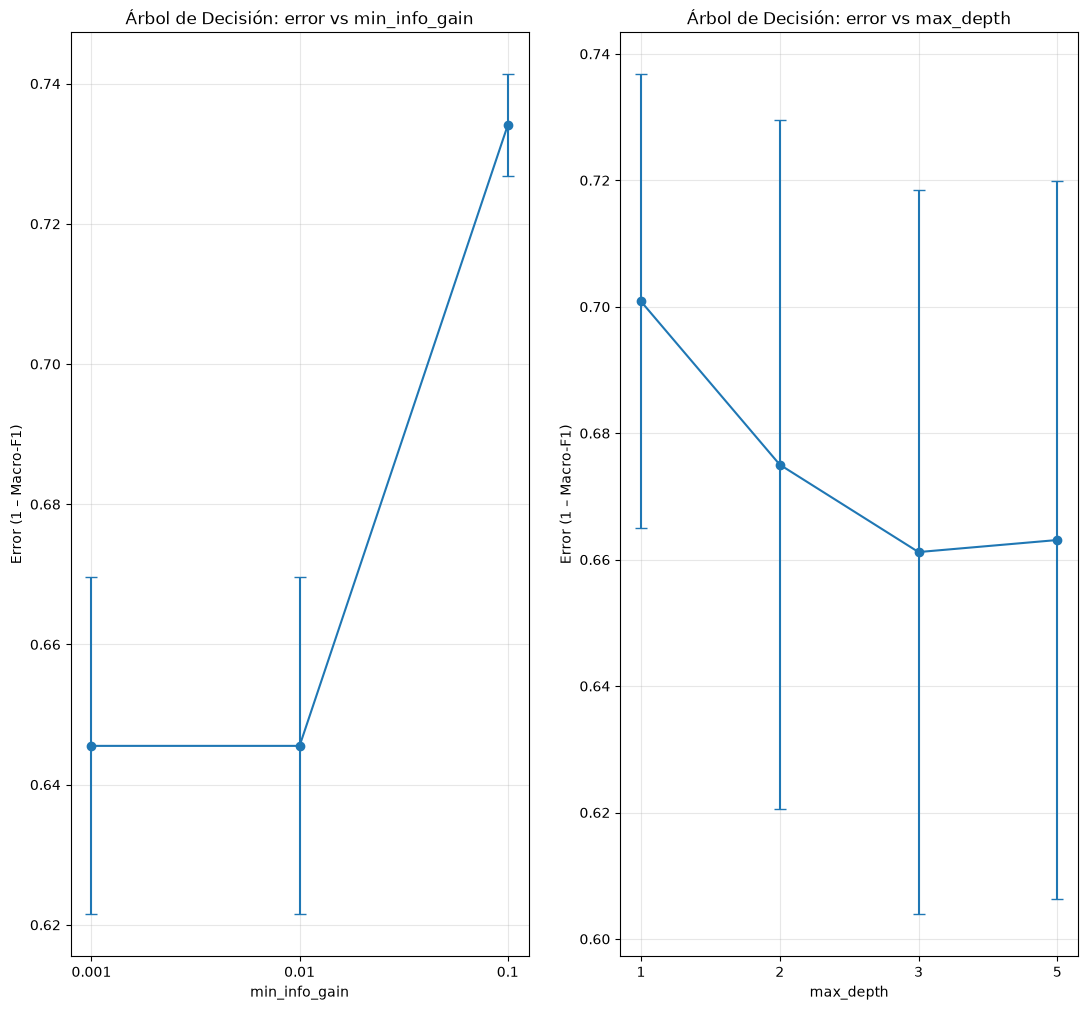

In [ ]:
import matplotlib.pyplot as plt

results_dt = resultados_cv_arbol_df

def plot_param(ax, results, col, title, xlabel, order):
    df = results.copy()
    df['_x'] = df[col].astype(str)
    g = df.groupby('_x')['f1_macro_promedio']
    means = g.mean().reindex([str(x) for x in order])
    stds  = g.std().reindex([str(x) for x in order]).fillna(0)
    ax.errorbar(means.index, 1 - means.values, yerr=stds.values,
                marker='o', capsize=4, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Error (1 – Macro-F1)')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(13, 12))

plot_param(axes[0], results_dt,
           'min_info_gain',
           'Árbol de Decisión: error vs min_info_gain',
           'min_info_gain',
           order=[0.001, 0.01, 0.1])

plot_param(axes[1], results_dt,
           'max_depth',
           'Árbol de Decisión: error vs max_depth',
           'max_depth',
           order=[1, 2, 3, 5])

### Reentrenamiento con los mejores hiperparámetros

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

# Elijo una combinación de hiperparámetros en caso de que haya más de una
fila = mejores_filas_arbol.iloc[0]
mejor_min_info_gain = 0.01
mejor_max_depth = fila['max_depth']

arbol_decision_optimizado = ArbolDecisionID3(min_info_gain=mejor_min_info_gain, max_depth=mejor_max_depth)
arbol_decision_optimizado.fit(X_train, Y_train)

predicciones_arbol_optimizado = arbol_decision_optimizado.predict(X_test)

print(f"Accuracy (min_info_gain={mejor_min_info_gain}, max_depth={mejor_max_depth}):", accuracy_score(Y_test, predicciones_arbol_optimizado))
print()
print(classification_report(Y_test, predicciones_arbol_optimizado, zero_division=0))
print("Matriz de confusión (orden de clases:", list(arbol_decision_optimizado.classes_), "):")                  


print(confusion_matrix(Y_test, predicciones_arbol_optimizado, labels=arbol_decision_optimizado.classes_))

Accuracy (min_info_gain=0.01, max_depth=3.0): 0.4067796610169492

              precision    recall  f1-score   support

           E       0.30      0.32      0.31       131
           L       0.46      0.52      0.49       190
           V       0.44      0.34      0.39       151

    accuracy                           0.41       472
   macro avg       0.40      0.39      0.39       472
weighted avg       0.41      0.41      0.41       472

Matriz de confusión (orden de clases: ['E', 'L', 'V'] ):
[[42 57 32]
 [58 98 34]
 [40 59 52]]


### **Random Forest (scikit-learn)**

### Pipeline de preprocesamiento

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(fill_value='missing', strategy='constant')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))],
)

preprocessing = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numeric_features),
        ('categorical', categorical_pipeline, categorical_features),
    ],
)

pipeline_rf = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestClassifier(random_state=62))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__min_samples_leaf': [1, 5, 10, 20]
}

### Entrenamiento

In [68]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

X_train_rf = X_train.copy()
Y_train_rf = Y_train.copy()

cv_temporal = TimeSeriesSplit(n_splits=5)

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv_temporal,
    n_jobs=-1,
    refit=True
)

grid_search_rf.fit(X_train, Y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=62))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [ ]:
print(f"Mejor F1-macro promedio (CV): {grid_search_rf.best_score_:.4f}\n")
print(f"Mejores parámetros: {grid_search_rf.best_params_}")

Mejor F1-macro promedio (CV): 0.3987

Mejores parámetros: {'model__min_samples_leaf': 1, 'model__n_estimators': 100}


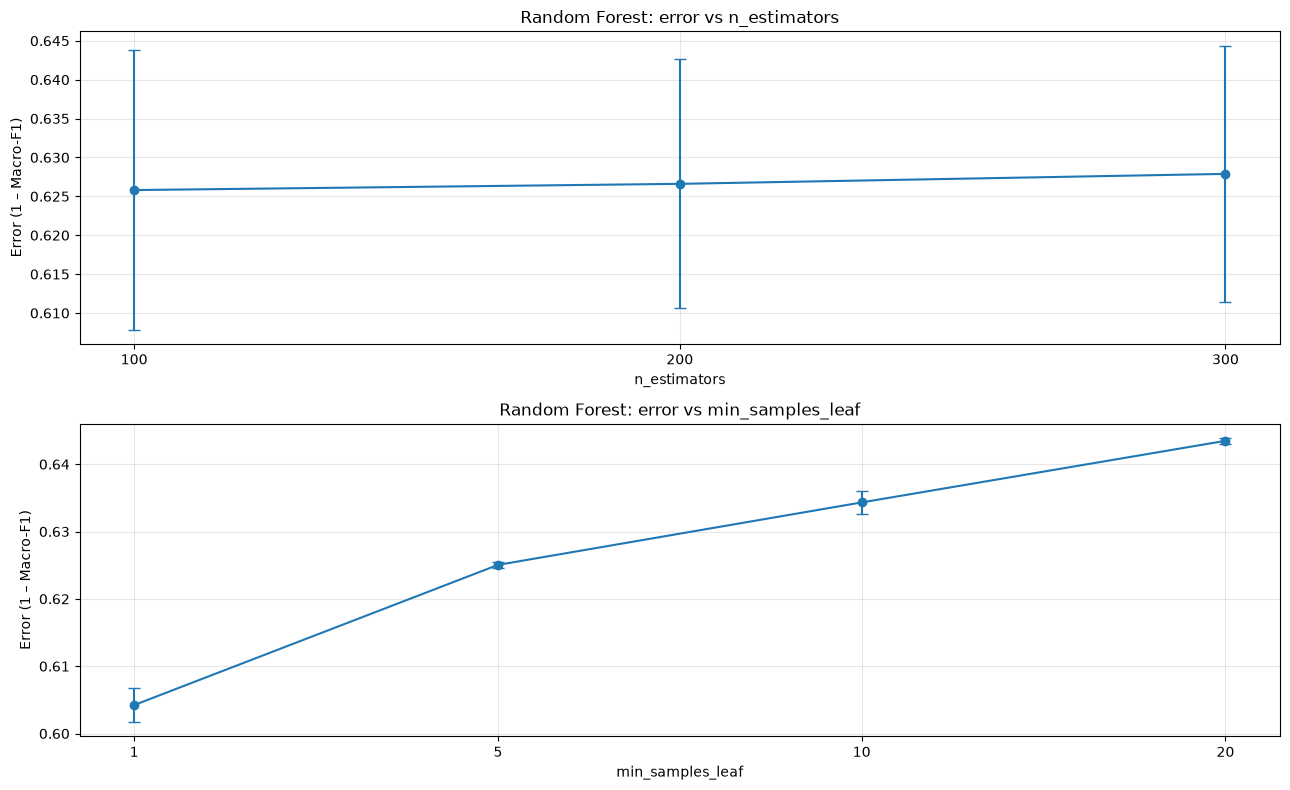

In [74]:
import matplotlib.pyplot as plt

results_rf = pd.DataFrame(grid_search_rf.cv_results_)
grid_search_rf.cv_results_

def plot_param(ax, results, col, title, xlabel, order):
    df = results.copy()
    df['_x'] = df[col].astype(str)
    g = df.groupby('_x')['mean_test_score']
    means = g.mean().reindex([str(x) for x in order])
    stds  = g.std().reindex([str(x) for x in order]).fillna(0)
    ax.errorbar(means.index, 1 - means.values, yerr=stds.values,
                marker='o', capsize=4, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Error (1 – Macro-F1)')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

plot_param(axes[0], results_rf,
           'param_model__n_estimators',
           'Random Forest: error vs n_estimators',
           'n_estimators',
           order=[100, 200, 300])

plot_param(axes[1], results_rf,
           'param_model__min_samples_leaf',
           'Random Forest: error vs min_samples_leaf',
           'min_samples_leaf',
           order=[1, 5, 10, 20])

plt.tight_layout()
plt.show()

### Métricas de evaluación sobre el conjunto de test

Se evalúan ambos modelos sobre los partidos de 2024 y 2025. La tabla resumen presenta
accuracy y macro-F1; el reporte detallado desglosa precisión, recall y F1 por cada clase.

El **macro-F1** promedia el F1 de las tres clases sin tener en cuenta su frecuencia,
por lo que penaliza de forma equitativa los errores en clases poco representadas como
empates y victorias visitantes.

=== Árbol de Decisión ===
              precision    recall  f1-score   support

           E       0.30      0.32      0.31       131
           L       0.46      0.52      0.49       190
           V       0.44      0.34      0.39       151

    accuracy                           0.41       472
   macro avg       0.40      0.39      0.39       472
weighted avg       0.41      0.41      0.41       472

=== Random Forest ===
              precision    recall  f1-score   support

           E       0.19      0.10      0.13       131
           L       0.47      0.69      0.56       190
           V       0.50      0.42      0.45       151

    accuracy                           0.44       472
   macro avg       0.39      0.40      0.38       472
weighted avg       0.40      0.44      0.41       472



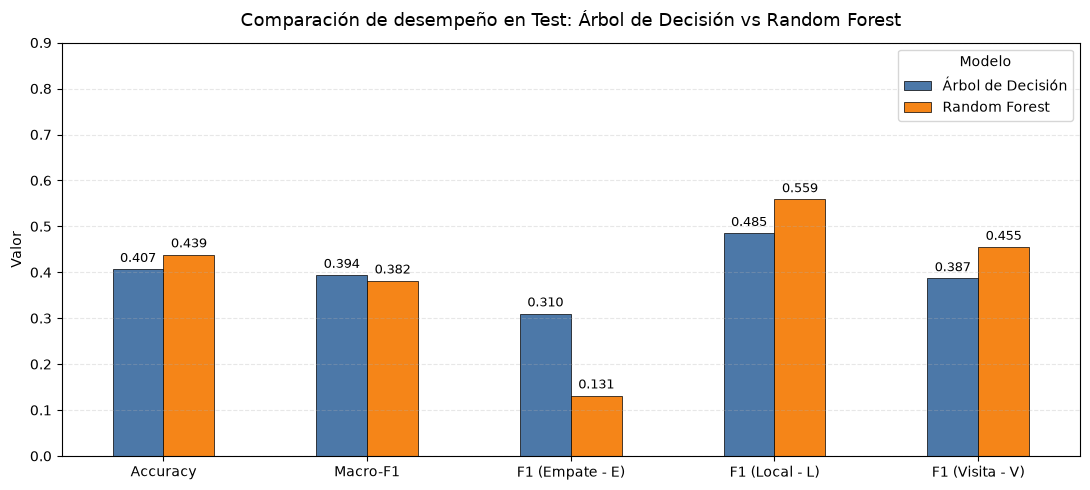

In [77]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

y_pred_dt = arbol_decision_optimizado.predict(X_test)
y_pred_rf = grid_search_rf.predict(X_test)

print('=== Árbol de Decisión ===')
print(classification_report(Y_test, y_pred_dt))

print('=== Random Forest ===')
print(classification_report(Y_test, y_pred_rf))


f1_dt = f1_score(Y_test, y_pred_dt, average=None, labels=['E', 'L', 'V'])
f1_rf = f1_score(Y_test, y_pred_rf, average=None, labels=['E', 'L', 'V'])

comparacion_df = pd.DataFrame({
    'Árbol de Decisión': [
        accuracy_score(Y_test, y_pred_dt),
        f1_score(Y_test, y_pred_dt, average='macro'),
        f1_dt[0], f1_dt[1], f1_dt[2]
    ],
    'Random Forest': [
        accuracy_score(Y_test, y_pred_rf),
        f1_score(Y_test, y_pred_rf, average='macro'),
        f1_rf[0], f1_rf[1], f1_rf[2]
    ]
}, index=['Accuracy', 'Macro-F1', 'F1 (Empate - E)', 'F1 (Local - L)', 'F1 (Visita - V)'])

ax = comparacion_df.plot(
    kind='bar',
    figsize=(11, 5),
    rot=0,
    color=['#4C78A8', '#F58518'],
    edgecolor='black',
    linewidth=0.5
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

ax.set_title('Comparación de desempeño en Test: Árbol de Decisión vs Random Forest', fontsize=13, pad=12)
ax.set_ylabel('Valor')
ax.set_ylim(0, 0.9)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Modelo', frameon=True)
plt.tight_layout()
plt.show()

## 3. Naive Bayes

En este seccion se realizará el entrenamiento en busqueda de los mejores hiperparametros para el algoritmo.

---
### 6. Selección de Hiperparámetros con Cross-Validation

Se aplica **validación cruzada temporal** sobre el conjunto de **entrenamiento** (nunca sobre el conjunto de evaluación 2024-2025, para no filtrar información) con el objetivo de elegir el mejor valor del hiperparámetro `m` (suavizado m-estimate) del `NaiveBayes` propio.

* Valores de `m` evaluados: `[0.1, 0.5, 1, 2, 5, 10, 20, 50]`.
* Se usa `TimeSeriesSplit` con 5 particiones, respetando el orden temporal de los partidos.
* En cada partición se entrena con partidos anteriores y se valida con partidos posteriores.
* Métrica de selección: **F1-macro promedio** entre las particiones (pondera por igual a las 3 clases, sin favorecer a `L` por ser mayoritaria). También se registra el accuracy como referencia.


In [29]:
from functions.naive_bayes import NaiveBayes
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, accuracy_score


valores_m = [0.1, 0.5, 1, 2, 5, 10, 20, 50]
cantidad_folds = 5

kf = TimeSeriesSplit(n_splits=cantidad_folds)

resultados_cv = []
for m in valores_m:
    f1_folds = []
    accuracy_folds = []
    for indice_train, indice_val in kf.split(X_train):
        X_train_fold = X_train.iloc[indice_train]
        X_val_fold = X_train.iloc[indice_val]
        y_train_fold = Y_train.iloc[indice_train]
        y_val_fold = Y_train.iloc[indice_val]

        modelo_fold = NaiveBayes(m=m)
        modelo_fold.fit(X_train_fold, y_train_fold)
        predicciones_fold = modelo_fold.predict(X_val_fold)

        f1_folds.append(f1_score(y_val_fold, predicciones_fold, average='macro'))
        accuracy_folds.append(accuracy_score(y_val_fold, predicciones_fold))

    resultados_cv.append({
        'm': m,
        'f1_macro_promedio': np.mean(f1_folds),
        'f1_macro_std': np.std(f1_folds),
        'accuracy_promedio': np.mean(accuracy_folds),
        'accuracy_std': np.std(accuracy_folds),
    })

resultados_cv_df = pd.DataFrame(resultados_cv).sort_values('f1_macro_promedio', ascending=False).reset_index(drop=True)
resultados_cv_df


,m,f1_macro_promedio,f1_macro_std,accuracy_promedio,accuracy_std
0,10.0,0.407555,0.034079,0.450509,0.047024
1,2.0,0.407181,0.033868,0.450672,0.045747
2,5.0,0.407049,0.034067,0.450346,0.046769
3,1.0,0.406946,0.033344,0.450672,0.045134
4,0.1,0.406620,0.033100,0.450346,0.044297
5,0.5,0.406405,0.032931,0.450102,0.044409
6,20.0,0.406234,0.032910,0.449695,0.047340
7,50.0,0.404014,0.029611,0.449939,0.048340


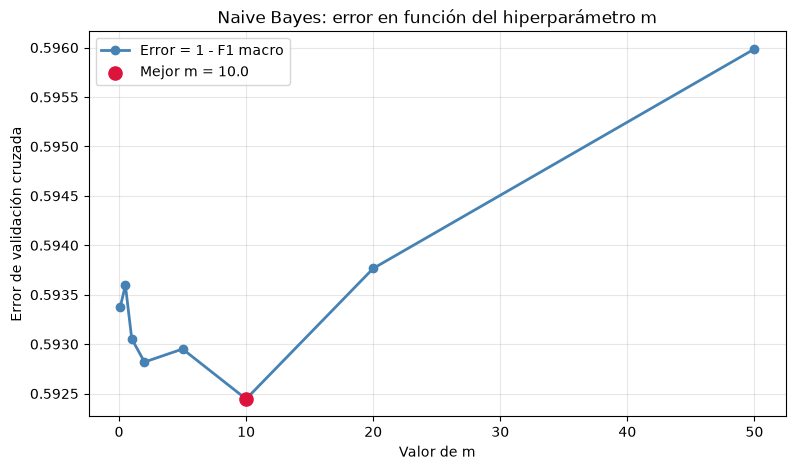

,m,f1_macro_promedio,error_f1_macro
0,0.1,0.406620,0.593380
1,0.5,0.406405,0.593595
2,1.0,0.406946,0.593054
3,2.0,0.407181,0.592819
4,5.0,0.407049,0.592951
5,10.0,0.407555,0.592445
6,20.0,0.406234,0.593766
7,50.0,0.404014,0.595986


In [30]:
import matplotlib.pyplot as plt

resultados_cv_ordenados = resultados_cv_df.sort_values('m').reset_index(drop=True).copy()
resultados_cv_ordenados['error_f1_macro'] = 1 - resultados_cv_ordenados['f1_macro_promedio']
mejor_fila_plot = resultados_cv_ordenados.loc[resultados_cv_ordenados['f1_macro_promedio'].idxmax()]

plt.figure(figsize=(9, 5))
plt.plot(
    resultados_cv_ordenados['m'],
    resultados_cv_ordenados['error_f1_macro'],
    marker='o',
    linewidth=2,
    color='steelblue',
    label='Error = 1 - F1 macro'
)
plt.scatter(
    mejor_fila_plot['m'],
    mejor_fila_plot['error_f1_macro'],
    color='crimson',
    s=90,
    zorder=3,
    label=f"Mejor m = {mejor_fila_plot['m']}"
)
plt.xlabel('Valor de m')
plt.ylabel('Error de validación cruzada')
plt.title('Naive Bayes: error en función del hiperparámetro m')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

resultados_cv_ordenados[['m', 'f1_macro_promedio', 'error_f1_macro']]


In [31]:
mejor_fila = resultados_cv_df.iloc[0]
mejor_m = mejor_fila['m']

print(f"Mejor hiperparámetro encontrado: m = {mejor_m}")
print(f"F1-macro promedio (CV): {mejor_fila['f1_macro_promedio']:.4f}")
print(f"Accuracy promedio (CV): {mejor_fila['accuracy_promedio']:.4f}")


Mejor hiperparámetro encontrado: m = 10.0
F1-macro promedio (CV): 0.4076
Accuracy promedio (CV): 0.4505


#### Entrenamiento final con el mejor `m` encontrado

Se reentrena el `NaiveBayes` propio con **todo** el conjunto de entrenamiento (sin folds) usando `mejor_m`, y se evalúa sobre el conjunto de evaluación real (2024-2025), para comparar contra el modelo baseline (`m=1.0`).


In [32]:
naive_bayes_optimizado = NaiveBayes(m=mejor_m)
naive_bayes_optimizado.fit(X_train, Y_train)

predicciones_nb_optimizado = naive_bayes_optimizado.predict(X_test)

print(f"Accuracy (m={mejor_m}):", accuracy_score(Y_test, predicciones_nb_optimizado))
print()
print(classification_report(Y_test, predicciones_nb_optimizado))
print("Matriz de confusión (orden de clases:", naive_bayes_optimizado.clases_, "):")
print(confusion_matrix(Y_test, predicciones_nb_optimizado, labels=naive_bayes_optimizado.clases_))


Accuracy (m=10.0): 0.4322033898305085

              precision    recall  f1-score   support

           E       0.35      0.13      0.19       131
           L       0.46      0.58      0.51       190
           V       0.42      0.51      0.46       151

    accuracy                           0.43       472
   macro avg       0.41      0.41      0.39       472
weighted avg       0.42      0.43      0.41       472

Matriz de confusión (orden de clases: ['E', 'L', 'V'] ):
[[ 17  65  49]
 [ 21 110  59]
 [ 11  63  77]]


---
### 7. Comparación con `CategoricalNB` de scikit-learn

* Se usa `OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=k)`, reservando un índice extra (`k`) por columna para valores no vistos en entrenamiento.
* Se informa a `CategoricalNB` esa cantidad real de categorías por columna vía `min_categories`, para que reserve espacio (y probabilidad suavizada) para ese valor "desconocido".
* Se usa `alpha=1.0` (suavizado Laplace estándar de sklearn) como punto de comparación. No es igual a m, pero ambos suavizan las probabilidades para evitar ceros.


In [34]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

X_train_ord = X_train.copy()
X_test_ord = X_test.copy()
cantidad_categorias = []
atributos_NB = numeric_features + categorical_features

for columna in atributos_NB:
    categorias_train = sorted(X_train[columna].unique())
    valor_desconocido = len(categorias_train)  # índice reservado para valores no vistos en entrenamiento

    encoder = OrdinalEncoder(
        categories=[categorias_train],
        handle_unknown='use_encoded_value',
        unknown_value=valor_desconocido,
    )
    X_train_ord[columna] = encoder.fit_transform(X_train[[columna]])
    X_test_ord[columna] = encoder.transform(X_test[[columna]])
    cantidad_categorias.append(valor_desconocido + 1)

categorical_nb = CategoricalNB(alpha=1.0, min_categories=cantidad_categorias)
categorical_nb.fit(X_train_ord, Y_train)

predicciones_categorical_nb = categorical_nb.predict(X_test_ord)
predicciones_categorical_nb[:5]


array(['L', 'L', 'L', 'L', 'L'], dtype='<U1')

In [35]:
print("Accuracy:", accuracy_score(Y_test, predicciones_categorical_nb))
print()
print(classification_report(Y_test, predicciones_categorical_nb))
print("Matriz de confusión (orden de clases:", list(categorical_nb.classes_), "):")
print(confusion_matrix(Y_test, predicciones_categorical_nb, labels=categorical_nb.classes_))


Accuracy: 0.4364406779661017

              precision    recall  f1-score   support

           E       0.35      0.13      0.19       131
           L       0.47      0.59      0.52       190
           V       0.42      0.51      0.46       151

    accuracy                           0.44       472
   macro avg       0.41      0.41      0.39       472
weighted avg       0.42      0.44      0.41       472

Matriz de confusión (orden de clases: [np.str_('E'), np.str_('L'), np.str_('V')] ):
[[ 17  65  49]
 [ 20 112  58]
 [ 11  63  77]]


In [36]:
from sklearn.metrics import f1_score, recall_score

comparacion = pd.DataFrame([
    {
        'modelo': 'NaiveBayes propio (m=mejor_m)',
        'accuracy': accuracy_score(Y_test, predicciones_nb_optimizado),
        'f1_macro': f1_score(Y_test, predicciones_nb_optimizado, average='macro'),
        'recall_E': recall_score(Y_test, predicciones_nb_optimizado, labels=['E'], average='macro'),
    },
    {
        'modelo': 'CategoricalNB (sklearn, alpha=1.0)',
        'accuracy': accuracy_score(Y_test, predicciones_categorical_nb),
        'f1_macro': f1_score(Y_test, predicciones_categorical_nb, average='macro'),
        'recall_E': recall_score(Y_test, predicciones_categorical_nb, labels=['E'], average='macro'),
    },
])
comparacion


,modelo,accuracy,f1_macro,recall_E
0,NaiveBayes propio (m=mejor_m),0.432203,0.387080,0.129771
1,"CategoricalNB (sklearn, alpha=1.0)",0.436441,0.390192,0.129771


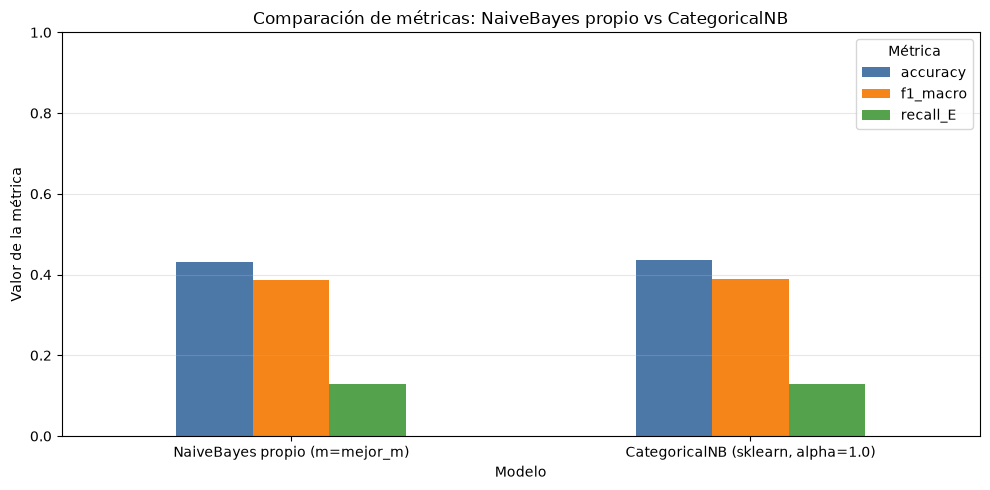

,accuracy,f1_macro,recall_E
modelo,,,
NaiveBayes propio (m=mejor_m),0.432203,0.387080,0.129771
"CategoricalNB (sklearn, alpha=1.0)",0.436441,0.390192,0.129771


In [37]:
metricas_plot = comparacion.set_index('modelo')[['accuracy', 'f1_macro', 'recall_E']]

ax = metricas_plot.plot(
    kind='bar',
    figsize=(10, 5),
    rot=0,
    color=['#4C78A8', '#F58518', '#54A24B']
)
ax.set_title('Comparación de métricas: NaiveBayes propio vs CategoricalNB')
ax.set_ylabel('Valor de la métrica')
ax.set_xlabel('Modelo')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

metricas_plot


### Comparacion Naive Bayes vs Arboles de Decision: